## Muhamad Fadhli Akbar(Cortana)

### Assignment Machine Learning 12-15
If **file code & images** cannot be accessed, you can use the repository link which can be accessed by using [this link!](https://github.com/Cortana-Coders/AICI-Tasks/blob/main/Assigment-Machine-Learning/Muhamad%20Fadhli%20Akbar-Cortana-ML%2001.ipynb "link github")

Create an ANN to perform classification using load_wine data from sklearn (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html#sklearn.datasets.load_wine). use loss function to perform multiclass classification, can be checked at: https://www.tensorflow.org/api_docs/python/tf/keras/losses

In [18]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [19]:
# Load the wine dataset
wine = load_wine()
X = wine.data
y = wine.target

In [20]:
# Convert target to categorical (one-hot encoding)
y_categorical = to_categorical(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# Build the ANN model
model = Sequential([
    Dense(64, activation='relu', input_shape=(13,)),  # 13 features in wine dataset
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes in wine dataset
])

# Compile the model using categorical crossentropy loss
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()

# Train the model
history = model.fit(X_train_scaled, y_train,
                   epochs=100,
                   batch_size=32,
                   validation_split=0.2,
                   verbose=1)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'\nTest accuracy: {test_accuracy:.4f}')

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,555 (13.89 KB)

 Trainable params: 3,555 (13.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.2272 - loss: 1.2065 - val_accuracy: 0.3448 - val_loss: 1.0936
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2912 - loss: 1.0917 - val_accuracy: 0.4138 - val_loss: 1.0321
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4154 - loss: 1.0417 - val_accuracy: 0.5172 - val_loss: 0.9810
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4612 - loss: 0.9901 - val_accuracy: 0.6552 - val_loss: 0.9358
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5882 - loss: 0.9537 - val_accuracy: 0.7931 - val_loss: 0.8922
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6276 - loss: 0.9123 - val_accuracy: 0.8621 - val_loss: 0.8464
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7224 - loss: 0.8335 - val_accuracy: 0.8621 - val_loss: 0.7958
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7648 - loss: 0.8125 - val_accuracy: 0.8966 - val_loss

In [23]:
# Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Print classification report
print('\nClassification Report:')
print(classification_report(y_test_classes, y_pred_classes, 
                          target_names=wine.target_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



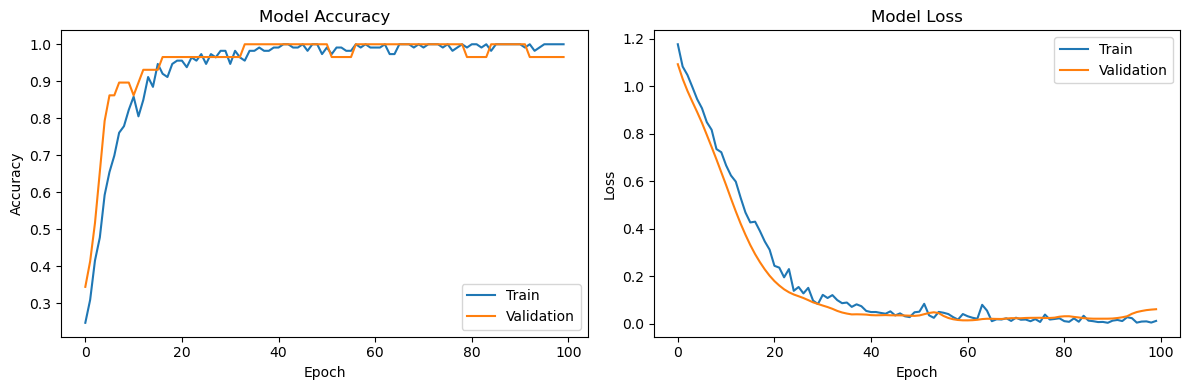

In [24]:
# Plot training history
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.tight_layout()
plt.show()

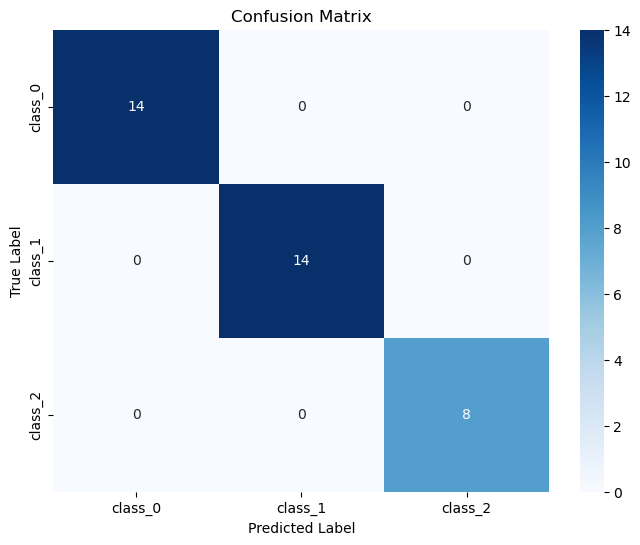

In [25]:
# Create confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [26]:
feature_importance = np.abs(model.layers[0].get_weights()[0]).mean(axis=1)
feature_importance_normalized = feature_importance / np.max(feature_importance)

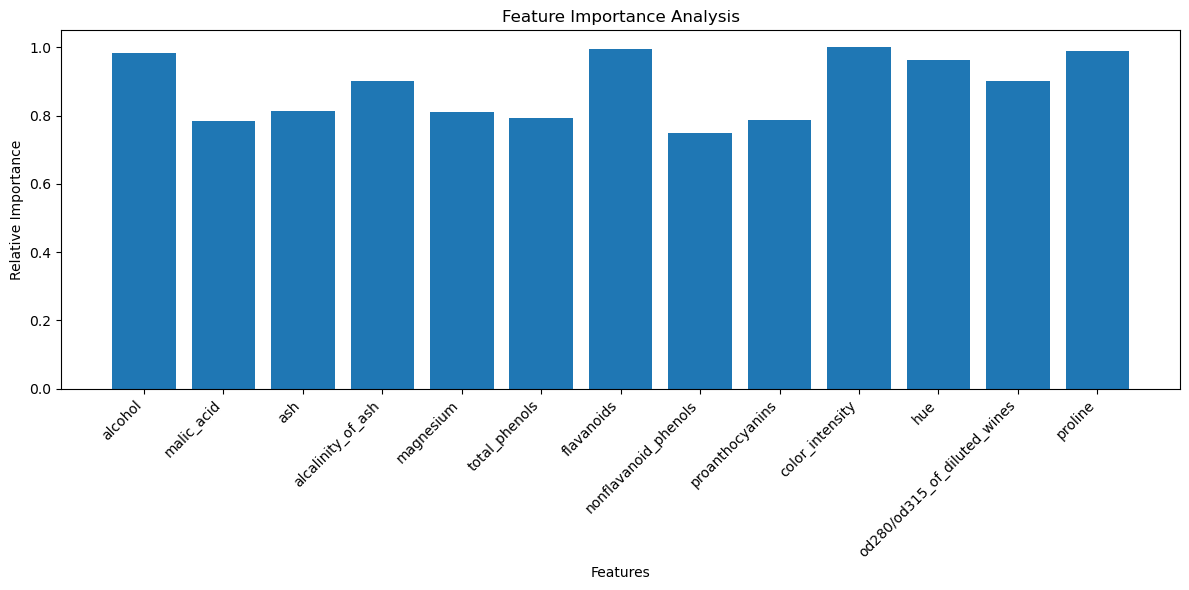

In [27]:
plt.figure(figsize=(12, 6))
plt.bar(wine.feature_names, feature_importance_normalized)
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance Analysis')
plt.xlabel('Features')
plt.ylabel('Relative Importance')
plt.tight_layout()
plt.show()

Create a simple RNN for the IBM stock prices dataset, use close as the series (or feature).

In [17]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Dense, LSTM

# Read the dataset
df = pd.read_csv('IBM stock price.csv')
data = df['Close'].values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences for training
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Parameters
sequence_length = 10
split_ratio = 0.8

# Create sequences
X, y = create_sequences(scaled_data, sequence_length)

# Split into training and testing sets
train_size = int(len(X) * split_ratio)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build the RNN model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1), return_sequences=True),
    LSTM(50, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Reshape input data for LSTM [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/50


e:\Anacondaa\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0301 - val_loss: 0.0102
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.1199e-04 - val_loss: 0.0017
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.4497e-04 - val_loss: 0.0012
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.6157e-04 - val_loss: 7.7393e-04
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.7544e-04 - val_loss: 8.1322e-04
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.8757e-04 - val_loss: 7.2303e-04
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.8864e-04 - val_loss: 6.8355e-04
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.8023e-04 - val_loss: 6.8712e-04
Epoch 9/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.9918e-04 - val_loss: 6.6633e-04
Epoch 10/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.8466e-04 - val_loss: 7.4095e-04
Epoch 11/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.9186e-04 - val_loss: 6.9471e-04
Epoch 12/50


In [13]:
# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions
train_predict = scaler.inverse_transform(train_predict)
y_train_inv = scaler.inverse_transform(y_train)
test_predict = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform(y_test)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [14]:
# Calculate RMSE
train_rmse = np.sqrt(np.mean((train_predict - y_train_inv) ** 2))
test_rmse = np.sqrt(np.mean((test_predict - y_test_inv) ** 2))
print(f'Train RMSE: {train_rmse:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')

Train RMSE: 0.76
Test RMSE: 0.88


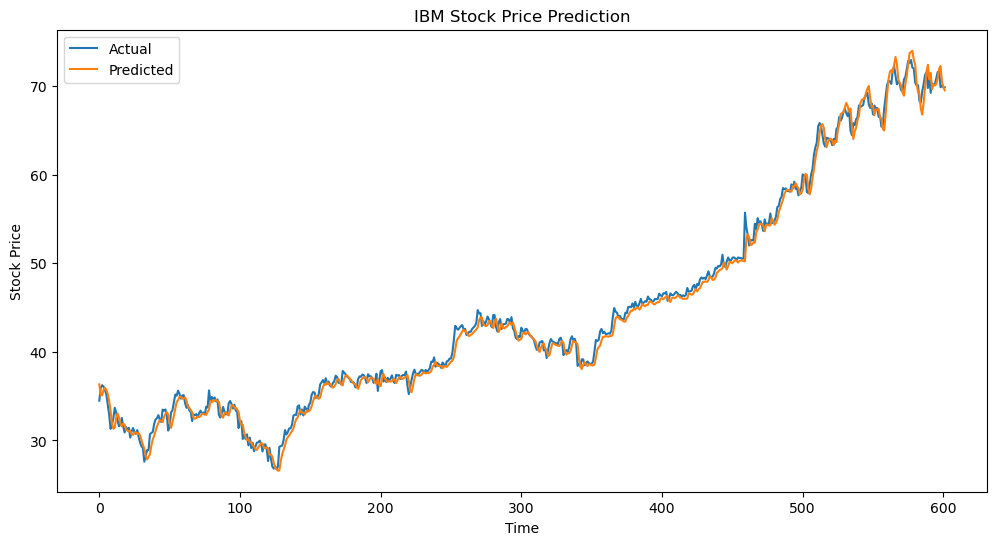

In [15]:
# Plot results
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual')
plt.plot(test_predict, label='Predicted')
plt.title('IBM Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

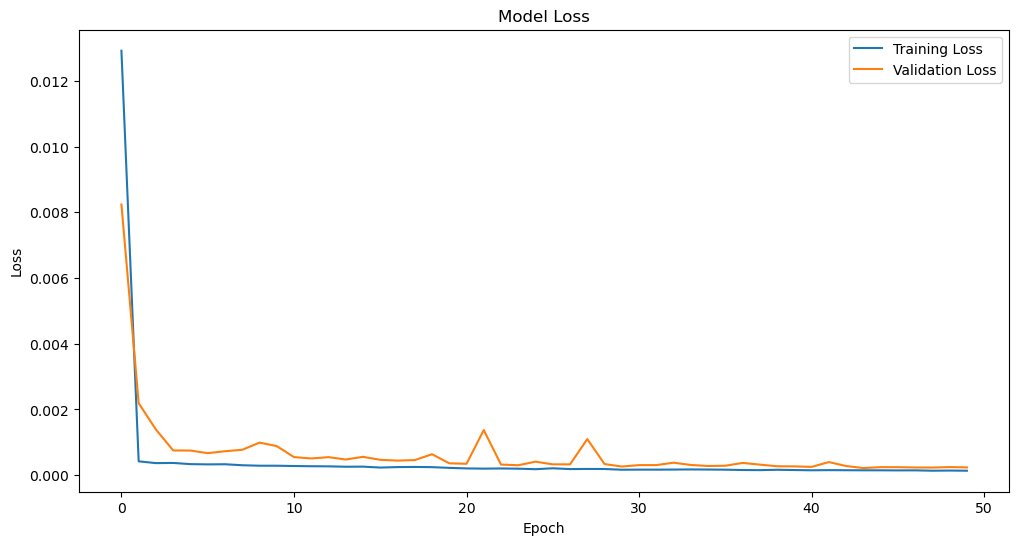

In [16]:
# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

If **file code & images** cannot be accessed, you can use the repository link which can be accessed by using [this link!](https://github.com/Cortana-Coders/AICI-Tasks/blob/main/Information-Retrieval/text_processing_practicum_steps01.ipynb "link github")

## THANK YOU😸

<p style="center">
    <img src="../Image/Animation/nature-banner.gif" width="80%" alt="Footer Background"></p>